MNIST: training a CNN and attacking it
device          : cuda (Tesla T4)
torch version   : 2.11.0+cu128
epochs          : 4
epsilons        : [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
iterations      : 10 | momentum decay: 1.0


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]



--- data ---
train images    : 60000 | test images: 10000
image shape     : (1, 28, 28) | pixel range: [0, 1]
classes         : ['0 - zero', '1 - one', '2 - two'] ... 9 - nine
batches         : 469 train / 20 test

--- model ---
4 conv layers + 2 fc, trainable parameters: 870,634

--- training (Adam, lr=1e-3, StepLR 0.5 every 2 epochs) ---
   epoch 1  batch 150/469  images 19200  running loss 0.3986
   epoch 1  batch 300/469  images 38400  running loss 0.2493
   epoch 1  batch 450/469  images 57600  running loss 0.1905
epoch 1/4 done | lr 0.00100 | train loss 0.1852 | test acc 98.33% | errors 167/10000 | 11.0s
   epoch 2  batch 150/469  images 19200  running loss 0.0546
   epoch 2  batch 300/469  images 38400  running loss 0.0502
   epoch 2  batch 450/469  images 57600  running loss 0.0477
epoch 2/4 done | lr 0.00100 | train loss 0.0480 | test acc 98.73% | errors 127/10000 | 9.1s
   epoch 3  batch 150/469  images 19200  running loss 0.0245
   epoch 3  batch 300/469  images 38400  runn

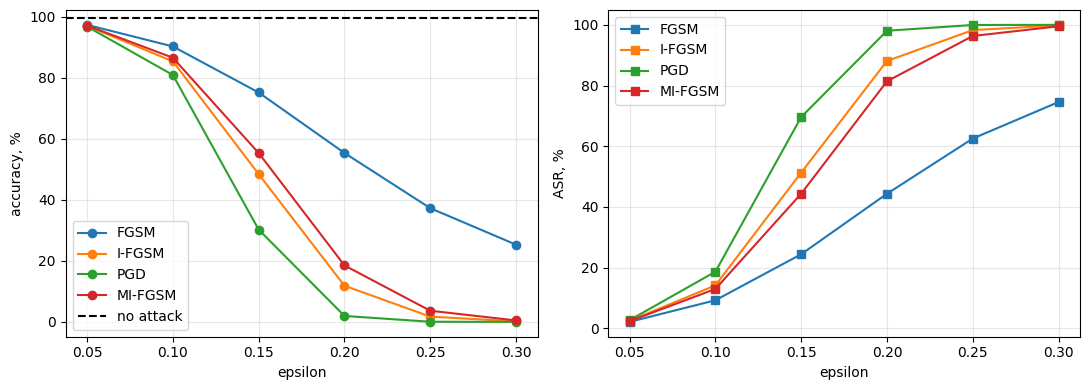


--- sample batch at eps = 0.20 ---
true labels        : [3, 9, 1, 9, 5, 9, 3, 0]
clean predictions  : [3, 9, 1, 9, 5, 9, 3, 0]
FGSM     predictions: [7, 5, 1, 7, 3, 9, 2, 0]  -> 5/8 fooled
I-FGSM   predictions: [7, 4, 7, 7, 3, 8, 2, 8]  -> 8/8 fooled
PGD      predictions: [7, 5, 7, 7, 3, 8, 2, 8]  -> 8/8 fooled
MI-FGSM  predictions: [7, 4, 7, 7, 3, 8, 2, 8]  -> 8/8 fooled


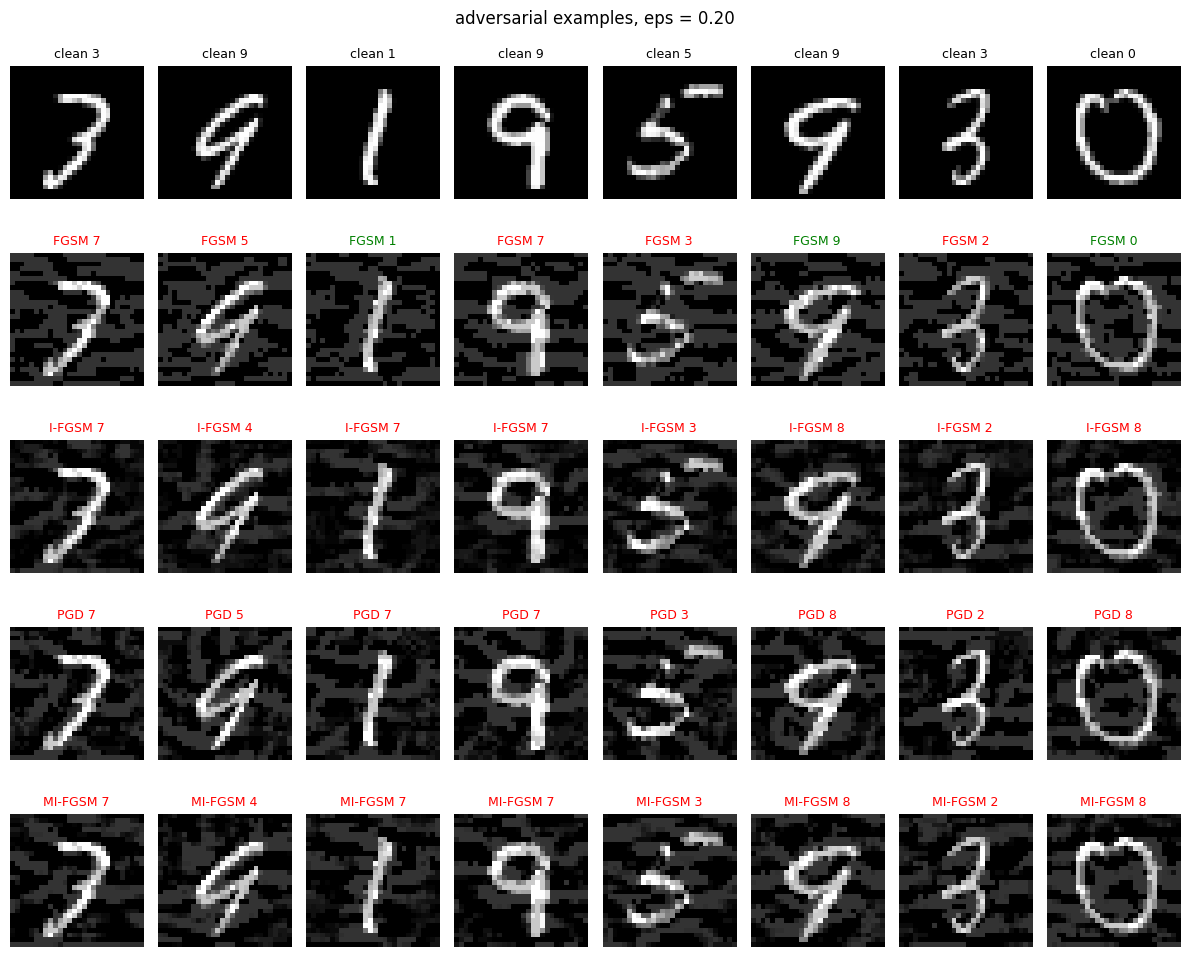


SUMMARY
recognition rate before attacks : 99.45%

ASR, %:
attack   FGSM  I-FGSM  MI-FGSM     PGD
eps                                   
0.05     2.12    2.45     2.35    2.68
0.10     9.24   14.15    12.96   18.65
0.15    24.41   51.32    44.36   69.61
0.20    44.34   88.09    81.40   98.05
0.25    62.53   98.27    96.33   99.96
0.30    74.56   99.84    99.53  100.00

accuracy under attack, %:
attack   FGSM  I-FGSM  MI-FGSM    PGD
eps                                  
0.05    97.34   97.01    97.11  96.78
0.10    90.26   85.38    86.56  80.90
0.15    75.17   48.41    55.33  30.22
0.20    55.35   11.84    18.50   1.94
0.25    37.26    1.72     3.65   0.04
0.30    25.30    0.16     0.47   0.00

strongest single result: PGD at eps=0.30 -> ASR 100.00% (accuracy 0.00%)
smallest eps with ASR > 90%: 0.20 (PGD)

files written: mnist_cnn.pt, results/train_log.csv, results/attack_results.csv,
               results/curves.png, results/examples.png


In [1]:
# MNIST classifier + adversarial attacks (FGSM, I-FGSM/PGD, MI-FGSM)

import os, time
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("results", exist_ok=True)

EPOCHS = 4
EPSILONS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
STEPS = 10          # iterations for I-FGSM / PGD / MI-FGSM
DECAY = 1.0         # momentum for MI-FGSM

print("=" * 70)
print("MNIST: training a CNN and attacking it")
print("=" * 70)
print("device          :", dev, "(" + (torch.cuda.get_device_name(0) if dev.type == "cuda" else "cpu") + ")")
print("torch version   :", torch.__version__)
print("epochs          :", EPOCHS)
print("epsilons        :", EPSILONS)
print("iterations      :", STEPS, "| momentum decay:", DECAY)

# ---------------- data (kept in [0,1], normalization is done inside the model,
# ---------------- so epsilon is measured in real pixel values) ----------------
tf = transforms.ToTensor()
train_set = datasets.MNIST("./data", train=True, download=True, transform=tf)
test_set = datasets.MNIST("./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=512, num_workers=2)

print("\n--- data ---")
print("train images    :", len(train_set), "| test images:", len(test_set))
print("image shape     :", tuple(train_set[0][0].shape), "| pixel range: [0, 1]")
print("classes         :", train_set.classes[:3], "...", train_set.classes[-1])
print("batches         :", len(train_loader), "train /", len(test_loader), "test")

# ---------------- model ----------------
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
                               nn.Dropout(0.3), nn.Linear(256, 10))

    def forward(self, x):
        return self.c(self.f((x - 0.1307) / 0.3081))

model = CNN().to(dev)
n_par = sum(p.numel() for p in model.parameters())
print("\n--- model ---")
print("4 conv layers + 2 fc, trainable parameters: %s" % format(n_par, ","))

# ---------------- training ----------------
@torch.no_grad()
def accuracy(loader):
    model.eval(); c = n = 0
    for x, y in loader:
        x, y = x.to(dev), y.to(dev)
        c += (model(x).argmax(1) == y).sum().item(); n += y.numel()
    return 100 * c / n

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.StepLR(opt, 2, 0.5)

print("\n--- training (Adam, lr=1e-3, StepLR 0.5 every 2 epochs) ---")
log, t0 = [], time.time()
for ep in range(1, EPOCHS + 1):
    model.train(); total, seen, t1 = 0.0, 0, time.time()
    for i, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward(); opt.step()
        total += loss.item(); seen += y.numel()
        if i % 150 == 0:
            print("   epoch %d  batch %3d/%d  images %5d  running loss %.4f"
                  % (ep, i, len(train_loader), seen, total / i))
    lr = opt.param_groups[0]["lr"]
    sch.step()
    acc = accuracy(test_loader)
    log.append({"epoch": ep, "loss": total / len(train_loader), "test_acc": acc})
    print("epoch %d/%d done | lr %.5f | train loss %.4f | test acc %.2f%% | errors %d/10000 | %.1fs"
          % (ep, EPOCHS, lr, total / len(train_loader), acc, round((100 - acc) * 100), time.time() - t1))

torch.save(model.state_dict(), "mnist_cnn.pt")
pd.DataFrame(log).to_csv("results/train_log.csv", index=False)
clean_acc = log[-1]["test_acc"]
print("total training time: %.0fs | weights saved to mnist_cnn.pt" % (time.time() - t0))
print("best epoch: %d (%.2f%%)" % (max(log, key=lambda r: r["test_acc"])["epoch"],
                                   max(r["test_acc"] for r in log)))
print("\n>>> RECOGNITION RATE BEFORE ATTACKS = %.2f%% (%d / %d correct)"
      % (clean_acc, round(clean_acc * 100), len(test_set)))

# ---------------- attacks ----------------
def grad(x, y):
    x = x.clone().detach().requires_grad_(True)
    g, = torch.autograd.grad(F.cross_entropy(model(x), y), x)
    return g

def project(x_adv, x, eps):
    return (x + (x_adv - x).clamp(-eps, eps)).clamp(0, 1).detach()

def fgsm(x, y, eps):
    return (x + eps * grad(x, y).sign()).clamp(0, 1).detach()

def ifgsm(x, y, eps, steps=STEPS, alpha=None, rand=False):
    alpha = alpha or eps / steps
    xa = x.clone().detach()
    if rand:
        xa = (xa + torch.empty_like(xa).uniform_(-eps, eps)).clamp(0, 1)
    for _ in range(steps):
        xa = project(xa + alpha * grad(xa, y).sign(), x, eps)
    return xa

def pgd(x, y, eps):
    return ifgsm(x, y, eps, alpha=2.5 * eps / STEPS, rand=True)

def mifgsm(x, y, eps, steps=STEPS, decay=DECAY):
    alpha, xa, mom = eps / steps, x.clone().detach(), torch.zeros_like(x)
    for _ in range(steps):
        g = grad(xa, y)
        g = g / (g.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)
        mom = decay * mom + g
        xa = project(xa + alpha * mom.sign(), x, eps)
    return xa

attacks = {"FGSM": fgsm, "I-FGSM": ifgsm, "PGD": pgd, "MI-FGSM": mifgsm}
descr = {"FGSM": "1 step, step = eps",
         "I-FGSM": "%d steps, step = eps/%d" % (STEPS, STEPS),
         "PGD": "%d steps, random start, step = 2.5*eps/%d" % (STEPS, STEPS),
         "MI-FGSM": "%d steps, step = eps/%d, momentum %.1f" % (STEPS, STEPS, DECAY)}

# ---------------- evaluation: accuracy under attack and ASR ----------------
# ASR is computed only on images the model classified correctly before the attack
def run_attack(attack, eps):
    model.eval()
    total = correct = fooled = adv_correct = 0
    l2, linf = 0.0, 0.0
    for x, y in test_loader:
        x, y = x.to(dev), y.to(dev)
        with torch.no_grad():
            pred = model(x).argmax(1)
        ok = pred == y
        total += y.numel(); correct += ok.sum().item()
        xa = attack(x, y, eps)
        with torch.no_grad():
            pred_adv = model(xa).argmax(1)
        adv_correct += (pred_adv == y).sum().item()
        fooled += ((pred_adv != y) & ok).sum().item()
        d = (xa - x).flatten(1)
        l2 += d.norm(dim=1).sum().item()
        linf = max(linf, d.abs().max().item())
    return (100 * adv_correct / total, 100 * fooled / correct,
            correct, fooled, l2 / total, linf)

print("\n" + "=" * 70)
print("ATTACKS (untargeted, L-inf budget, full test set of %d images)" % len(test_set))
print("=" * 70)

rows = []
for name, atk in attacks.items():
    print("\n%s -- %s" % (name, descr[name]))
    print("  %-6s %10s %10s %10s %10s %8s %7s" %
          ("eps", "adv acc", "ASR", "fooled", "of correct", "avg L2", "max Li"))
    t1 = time.time()
    for eps in EPSILONS:
        adv_acc, asr, corr, fooled, l2, linf = run_attack(atk, eps)
        rows.append({"attack": name, "eps": eps, "clean_acc": round(clean_acc, 2),
                     "adv_acc": round(adv_acc, 2), "ASR": round(asr, 2),
                     "fooled": fooled, "avg_L2": round(l2, 3)})
        print("  %-6.2f %9.2f%% %9.2f%% %10d %10d %8.3f %7.3f"
              % (eps, adv_acc, asr, fooled, corr, l2, linf))
    print("  accuracy dropped %.2f%% -> %.2f%% at eps=%.2f  (%.1fs)"
          % (clean_acc, adv_acc, EPSILONS[-1], time.time() - t1))

df = pd.DataFrame(rows)
df.to_csv("results/attack_results.csv", index=False)

# ---------------- plots ----------------
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for n in attacks:
    s = df[df.attack == n]; plt.plot(s.eps, s.adv_acc, "o-", label=n)
plt.axhline(clean_acc, ls="--", c="k", label="no attack")
plt.xlabel("epsilon"); plt.ylabel("accuracy, %"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
for n in attacks:
    s = df[df.attack == n]; plt.plot(s.eps, s.ASR, "s-", label=n)
plt.xlabel("epsilon"); plt.ylabel("ASR, %"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("results/curves.png", dpi=140); plt.show()

x, y = next(iter(DataLoader(test_set, batch_size=8, shuffle=True)))
x, y = x.to(dev), y.to(dev)
eps = 0.2
fig, ax = plt.subplots(len(attacks) + 1, 8, figsize=(12, 10))
with torch.no_grad():
    p = model(x).argmax(1)
for j in range(8):
    ax[0, j].imshow(x[j, 0].cpu(), cmap="gray"); ax[0, j].axis("off")
    ax[0, j].set_title("clean %d" % p[j], fontsize=9)

print("\n--- sample batch at eps = %.2f ---" % eps)
print("true labels        :", y.tolist())
print("clean predictions  :", p.tolist())
for i, (name, atk) in enumerate(attacks.items(), 1):
    xa = atk(x, y, eps)
    with torch.no_grad():
        pa = model(xa).argmax(1)
    print("%-8s predictions: %s  -> %d/8 fooled" % (name, pa.tolist(), (pa != y).sum().item()))
    for j in range(8):
        ax[i, j].imshow(xa[j, 0].cpu(), cmap="gray"); ax[i, j].axis("off")
        ax[i, j].set_title("%s %d" % (name, pa[j]), fontsize=9,
                           color="red" if pa[j] != y[j] else "green")
plt.suptitle("adversarial examples, eps = %.2f" % eps)
plt.tight_layout(); plt.savefig("results/examples.png", dpi=140); plt.show()

# ---------------- summary ----------------
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print("recognition rate before attacks : %.2f%%" % clean_acc)
print("\nASR, %:")
print(df.pivot(index="eps", columns="attack", values="ASR").round(2))
print("\naccuracy under attack, %:")
print(df.pivot(index="eps", columns="attack", values="adv_acc").round(2))
best = df.loc[df.ASR.idxmax()]
print("\nstrongest single result: %s at eps=%.2f -> ASR %.2f%% (accuracy %.2f%%)"
      % (best.attack, best.eps, best.ASR, best.adv_acc))
smallest = df[df.ASR > 90].sort_values("eps")
if len(smallest):
    r = smallest.iloc[0]
    print("smallest eps with ASR > 90%%: %.2f (%s)" % (r.eps, r.attack))
print("\nfiles written: mnist_cnn.pt, results/train_log.csv, results/attack_results.csv,")
print("               results/curves.png, results/examples.png")

